In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/passthrough_dataset.csv", parse_dates=["date"])
df = df.set_index("date")
df.head()


,brent,wti,usdmyr,ron95,ron97,diesel,cpi_transport,cpi_headline
date,,,,,,,,
2020-01-31,63.645455,57.519048,4.080110,2.0800,2.5725,2.1800,115.0,122.4
2020-02-29,55.657000,50.542632,4.159900,2.0680,2.3780,2.1340,113.9,122.4
2020-03-31,32.011364,29.207727,4.298409,1.6325,1.9275,1.8150,104.0,120.9
2020-04-30,18.378500,16.547619,4.352486,1.2625,1.5625,1.4675,90.0,117.6
2020-05-31,29.378947,28.562500,4.340906,1.3240,1.6240,1.4740,90.9,117.9


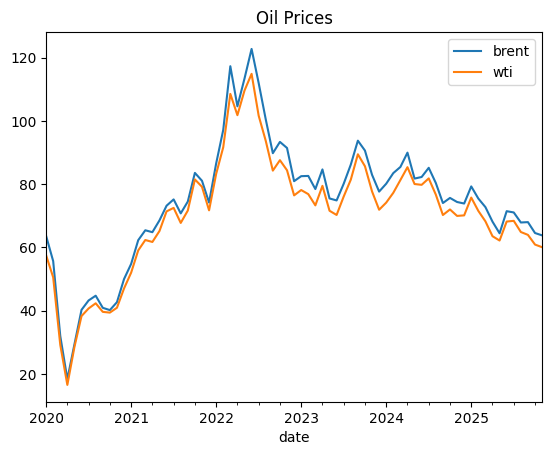

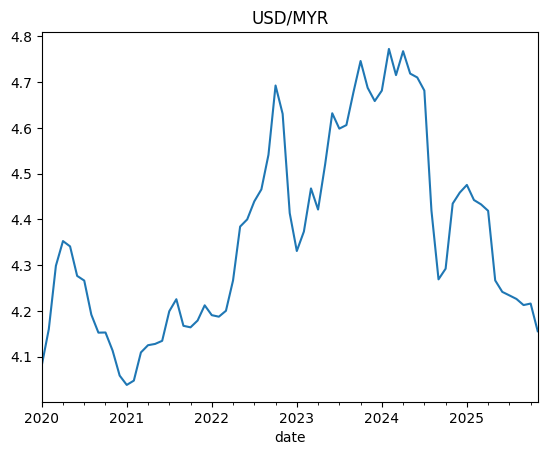

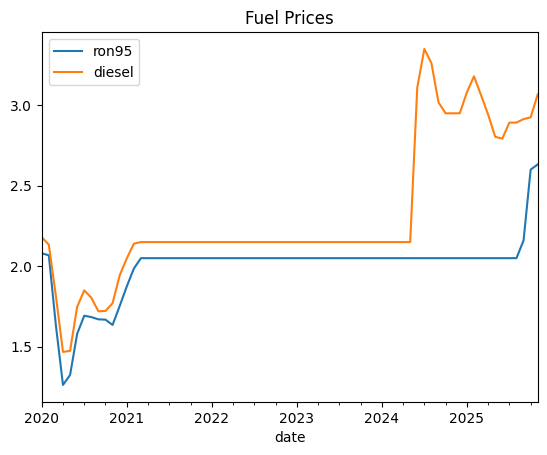

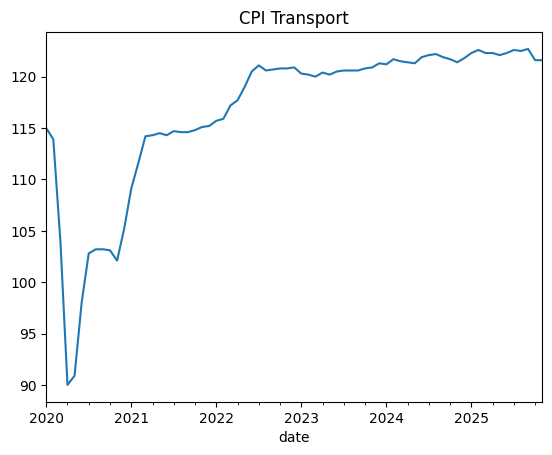

In [2]:
import matplotlib.pyplot as plt

df[["brent", "wti"]].plot(title="Oil Prices")
plt.show()

df["usdmyr"].plot(title="USD/MYR")
plt.show()

df[["ron95", "diesel"]].plot(title="Fuel Prices")
plt.show()

df["cpi_transport"].plot(title="CPI Transport")
plt.show()


In [3]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    res = adfuller(series.dropna())
    print(f"{name}: ADF p-value = {res[1]:.4f}")

for col in df.columns:
    adf_test(df[col], col)


brent: ADF p-value = 0.5259
wti: ADF p-value = 0.2715
usdmyr: ADF p-value = 0.6158
ron95: ADF p-value = 0.0000
ron97: ADF p-value = 0.3036
diesel: ADF p-value = 0.5196
cpi_transport: ADF p-value = 0.0000
cpi_headline: ADF p-value = 0.9008


In [3]:
# Calculate Table 4.1
desc_cols = ['brent', 'wti', 'ron97', 'ron95', 'diesel', 'usdmyr']
stats = df[desc_cols].describe().T[['mean', 'std', 'min', 'max']]
stats['CV (%)'] = (stats['std'] / stats['mean']) * 100
stats['Skewness'] = df[desc_cols].skew()
stats['Kurtosis'] = df[desc_cols].kurtosis()

print(stats.round(2))
# This output provides the exact numbers for Table 4.1 in the text above.

         mean    std    min     max  CV (%)  Skewness  Kurtosis
brent   74.38  19.95  18.38  122.71   26.82     -0.34      0.79
wti     70.45  18.80  16.55  114.84   26.69     -0.40      0.77
ron97    3.10   0.69   1.56    4.79   22.34     -0.21      0.13
ron95    2.00   0.20   1.26    2.63   10.12     -0.98      5.30
diesel   2.31   0.44   1.47    3.35   19.28      0.76     -0.27
usdmyr   4.37   0.21   4.04    4.77    4.85      0.43     -1.02


In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# 1. Load Data (Adjust path if necessary)
df = pd.read_csv('../data/processed/passthrough_dataset.csv', parse_dates=['date'], index_col='date')

# 2. Define Variables to Test
# (Log transformation is standard for elasticity interpretation)
variables = {
    'ln(Brent)': np.log(df['brent']),
    'ln(USD/MYR)': np.log(df['usdmyr']),
    'ln(RON97)': np.log(df['ron97']),
    'ln(RON95)': np.log(df['ron95']),
    'ln(CPI_Head)': np.log(df['cpi_headline']), 
    'ln(CPI_Trans)': np.log(df['cpi_transport'])
}

# 3. Run ADF Test Loop
results = []

for name, series in variables.items():
    # Test at Level
    adf_level = adfuller(series.dropna(), autolag='AIC')
    
    # Test at First Difference
    diff_series = series.diff().dropna()
    adf_diff = adfuller(diff_series, autolag='AIC')
    
    # Determine Order
    # If Level p-value < 0.05 -> I(0)
    # If Level > 0.05 AND Diff < 0.05 -> I(1)
    if adf_level[1] < 0.05:
        order = "I(0)"
    elif adf_diff[1] < 0.05:
        order = "I(1)"
    else:
        order = "I(2)+"

    results.append({
        'Variable': name,
        'ADF Stat (Level)': f"{adf_level[0]:.3f}",
        'p-value (Level)': f"{adf_level[1]:.4f}",
        'ADF Stat (1st Diff)': f"{adf_diff[0]:.3f}",
        'p-value (1st Diff)': f"{adf_diff[1]:.4f}",
        'Integration Order': order
    })

# 4. Create and Display Table
adf_table = pd.DataFrame(results)
print("=== Table 4.3: ADF Unit Root Test Results ===")
display(adf_table)

# Optional: Save to CSV for the thesis
# adf_table.to_csv('../data/outputs/table_4_3_adf_results.csv', index=False)

=== Table 4.3: ADF Unit Root Test Results ===


,Variable,ADF Stat (Level),p-value (Level),ADF Stat (1st Diff),p-value (1st Diff),Integration Order
0,ln(Brent),-1.776,0.3923,-6.286,0.0000,I(1)
1,ln(USD/MYR),-1.307,0.6260,-6.539,0.0000,I(1)
2,ln(RON97),-1.975,0.2976,-4.734,0.0001,I(1)
3,ln(RON95),-17.165,0.0000,-4.359,0.0004,I(0)
4,ln(CPI_Head),-0.514,0.8892,-5.463,0.0000,I(1)
5,ln(CPI_Trans),-6.067,0.0000,-4.878,0.0000,I(0)
